<a href="https://colab.research.google.com/github/Sneha17A/ML_Projects/blob/main/Image_Classification_Problem_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning an image classification model from Scratch

Fashion MNIST dataset
Consists of 70000 images of clothing

In [ ]:
#import all necessary packages
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [ ]:
(x_train,y_train),(x_test,y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape,y_train.shape)

(60000, 28, 28) (60000,)


In [ ]:
print(x_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


In [ ]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

What do these numbers mean?
Labels
Each training and test example is assigned to one of the following labels:

Label	Description
0	T-shirt/top
1	Trouser
2	Pullover
3	Dress
4	Coat
5	Sandal
6	Shirt
7	Sneaker
8	Bag
9	Ankle boot

In [ ]:
labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandle",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

In [ ]:
labels[y_train[0]]

'Ankle boot'

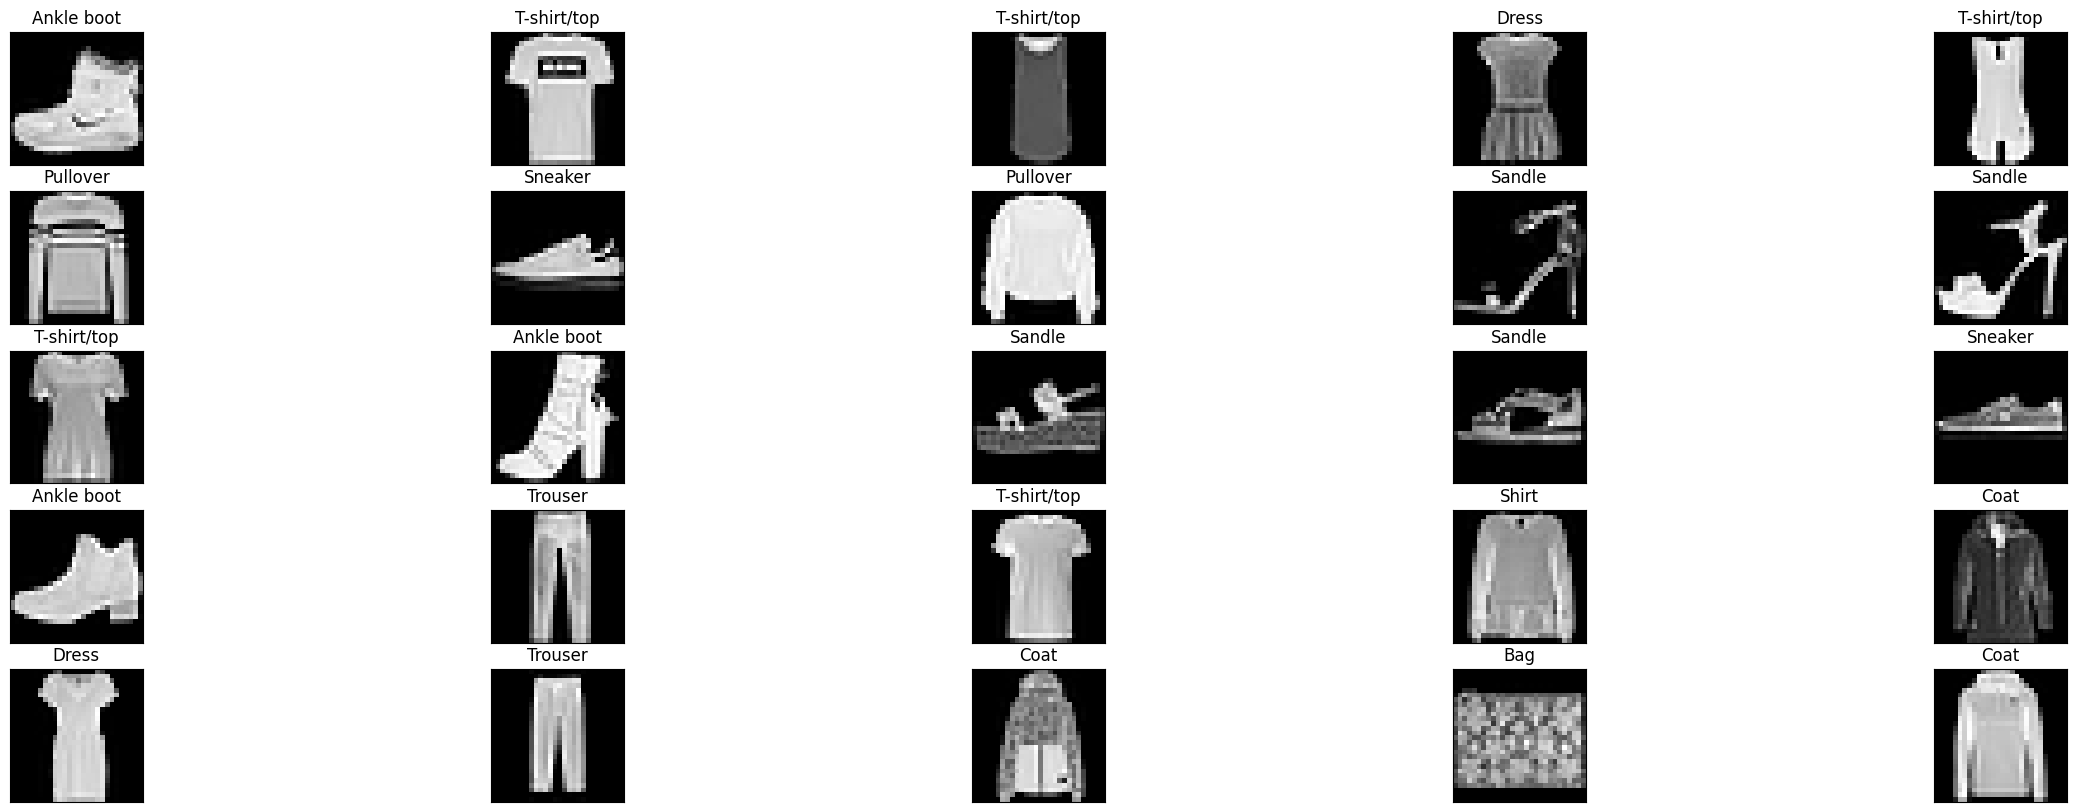

In [ ]:
fig, ax = plt.subplots(5,5,figsize=(30,10))
for i in range(25):
    axc = ax[i//5,i%5]
    axc.imshow(x_train[i],cmap="gray")
    axc.set_title(f"{labels[y_train[i]]}")
    axc.set_xticks([])
    axc.set_yticks([])

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
28*28

784

In [ ]:
input = keras.Input(shape=(28,28))
h = keras.layers.Flatten()(input)
h = keras.layers.Dense(256,activation="relu")(h)
output = keras.layers.Dense(10,activation="softmax")(h)
model = keras.Model(inputs=input,outputs=output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

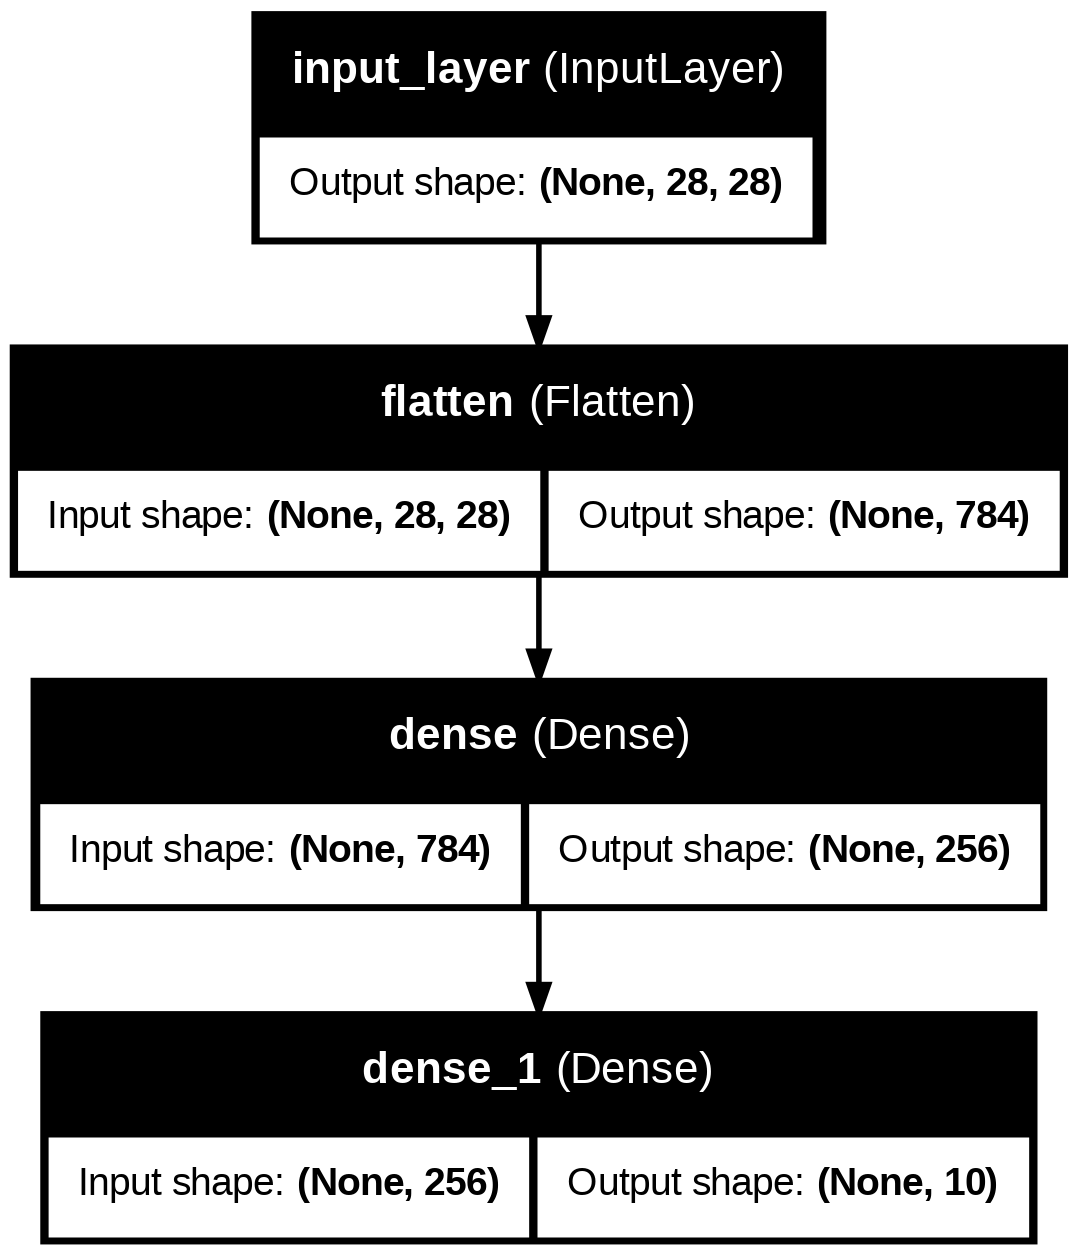

In [ ]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
model.compile(loss = "sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [ ]:
batch_size = 64
epochs = 20

history = model.fit(x_train,
                    y_train,
                    batch_size = batch_size,
                    epochs = epochs,
                    validation_split = 0.2)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8187 - loss: 0.5162 - val_accuracy: 0.8565 - val_loss: 0.4108
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8627 - loss: 0.3841 - val_accuracy: 0.8664 - val_loss: 0.3755
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8763 - loss: 0.3418 - val_accuracy: 0.8727 - val_loss: 0.3553
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8857 - loss: 0.3138 - val_accuracy: 0.8783 - val_loss: 0.3455
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8923 - loss: 0.2928 - val_accuracy: 0.8825 - val_loss: 0.3393
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8980 - loss: 0.2750 - val_accuracy: 0.8820 - val_loss: 0.3429
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9037 - loss: 0.2601 - val_accuracy: 0.8820 - val_loss: 0.3409
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9086 - loss: 0.2475 - val_accuracy: 0.

In [ ]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(history_dict["loss"]) +1)
  plt.plot(epochs, loss_values, "bo", label="Training Loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation Loss")
  plt.title("Training and Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

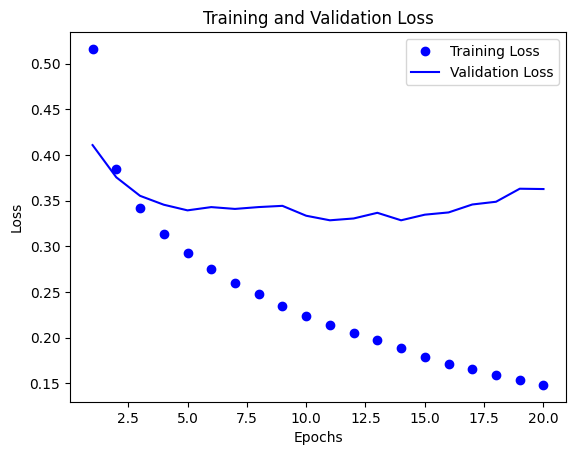

In [ ]:
plot_loss_curves(history)

In [ ]:
def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc_values = history_dict["accuracy"]
  val_acc_values = history_dict["val_accuracy"]
  epochs = range(1, len(history_dict["accuracy"]) + 1)
  plt.plot(epochs, acc_values, "bo", label="Training Accuracy")
  plt.plot(epochs, val_acc_values, "b", label="Validation Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

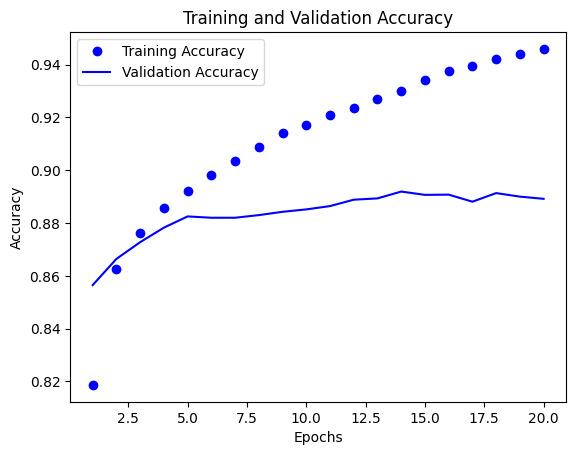

In [ ]:
plot_acc_curves(history)

In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8811 - loss: 0.3957


[0.39565277099609375, 0.8810999989509583]

In [ ]:
input = keras.Input(shape=(28,28))
h = keras.layers.Flatten()(input)
h = keras.layers.Dense(256,activation="relu")(h)
h = keras.layers.Dense(256,activation="relu")(h)
output = keras.layers.Dense(10,activation="softmax")(h)
model = keras.Model(inputs=input,outputs=output)

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = "sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
batch_size = 64
epochs = 20

history = model.fit(x_train,
                    y_train,
                    batch_size = batch_size,
                    epochs = epochs,
                    validation_split = 0.2)
model.evaluate(x_test,y_test)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8226 - loss: 0.4978 - val_accuracy: 0.8596 - val_loss: 0.3927
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8668 - loss: 0.3668 - val_accuracy: 0.8674 - val_loss: 0.3710
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8796 - loss: 0.3258 - val_accuracy: 0.8776 - val_loss: 0.3483
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8891 - loss: 0.2994 - val_accuracy: 0.8771 - val_loss: 0.3463
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8955 - loss: 0.2796 - val_accuracy: 0.8798 - val_loss: 0.3475
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9010 - loss: 0.2634 - val_accuracy: 0.8779 - val_loss: 0.3588
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9064 - loss: 0.2488 - val_accuracy: 0.8808 - val_loss: 0.3536
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9111 - loss: 0.2372 - val_accuracy: 0

[0.4539251923561096, 0.8805000185966492]